<a href="https://colab.research.google.com/github/afonsoamsantos-pixel/Projeto-CMO-Diabetes/blob/main/ProjetoCMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Carregar os dados
df = pd.read_csv('diabetes_preprocessed.csv')

from sklearn.model_selection import train_test_split

# 2. Separar as features (X) do target (y)
X = df.drop(columns=['target']).values
y = df['target'].values
p = X.shape[1]

# NOVA DIVISÃO DE DADOS (Passo A)
# Treino: 80% dos dados | Teste: 20% dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Dados carregados e divididos com sucesso!")
print(f"Treino: {X_train.shape[0]} pacientes | Teste: {X_test.shape[0]} pacientes")
print(f"Número de features (p): {p}")
# NOVA DIVISÃO DE DADOS (Passo A)
# Treino: 80% dos dados | Teste: 20% dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Dados carregados e divididos com sucesso!")
print(f"Treino: {X_train.shape[0]} pacientes | Teste: {X_test.shape[0]} pacientes")
print(f"Número de features (p): {p}")


✅ Dados carregados e divididos com sucesso!
Treino: 353 pacientes | Teste: 89 pacientes
Número de features (p): 10
✅ Dados carregados e divididos com sucesso!
Treino: 353 pacientes | Teste: 89 pacientes
Número de features (p): 10


Este primeiro bloco de código é responsável por:

1.  **Carregar os dados:** Ele lê o arquivo `diabetes_preprocessed.csv` em um DataFrame do pandas chamado `df`.
2.  **Separar features e target:** Divide o DataFrame em `X` (as variáveis independentes ou 'features', que são as características dos pacientes) e `y` (a variável dependente ou 'target', que é o que queremos prever, neste caso, a progressão da doença).
3.  **Determinar o número de features:** Calcula o número de colunas em `X` e armazena esse valor na variável `p`.
4.  **Imprimir informações:** Exibe mensagens informando que os dados foram carregados e a quantidade de pacientes e features presentes.

In [16]:
def generate_solution(num_features):
    """
    Gera um vetor de pesos aleatório de tamanho p+1.
    """
    return np.random.uniform(-1, 1, num_features + 1)

def fitness_function(solution_vector, X, y):
    """
    Avalia os pesos calculando as previsões e o Erro Quadrático Médio (MSE).
    """
    # Separar os pesos e o bias
    w = solution_vector[:-1]
    b = solution_vector[-1]

    # Calcular y = Xw + b
    y_pred = np.dot(X, w) + b

    # Calcular o MSE
    mse = mean_squared_error(y, y_pred)

    # Devolve o negativo para o algoritmo tentar aproximar de zero (maximizar)
    return -mse

# Vamos testar se o motor está a funcionar
vetor_teste = generate_solution(p)
score = fitness_function(vetor_teste, X, y)

print(f"✅ Funções prontas!")
print(f"Vetor gerado com tamanho: {len(vetor_teste)}")
print(f"O Fitness (MSE negativo) desta solução aleatória é: {score:.2f}")

✅ Funções prontas!
Vetor gerado com tamanho: 11
O Fitness (MSE negativo) desta solução aleatória é: -29048.12


Este segundo bloco define as funções essenciais para o algoritmo de Otimização por Enxame de Partículas (PSO):

1.  **`generate_solution(num_features)`:** Esta função cria um vetor de pesos aleatório. O tamanho do vetor é `num_features + 1`, porque inclui um peso para cada feature e mais um para o termo de 'bias' (interseção) no modelo de regressão linear.
2.  **`fitness_function(solution_vector, X, y)`:** Esta é a função mais importante, pois avalia a 'qualidade' de um determinado conjunto de pesos (uma 'solução').
    *   Ela separa os pesos (`w`) e o bias (`b`) do vetor de solução.
    *   Calcula as previsões (`y_pred`) usando a fórmula de regressão linear: `y_pred = Xw + b`.
    *   Calcula o Erro Quadrático Médio (MSE) entre as previsões e os valores reais (`y`).
    *   Retorna o **negativo do MSE**. O PSO é um algoritmo de maximização, então, ao maximizar o MSE negativo, estamos efetivamente minimizando o MSE real, que é o nosso objetivo para encontrar os melhores pesos.
3.  **Teste inicial:** O código gera um vetor de teste aleatório e calcula seu 'fitness' (MSE negativo) para demonstrar que as funções estão operacionais.

In [17]:
import numpy as np

def particle_swarm_optimization(fitness_func, X, y, num_features, num_particles=30, max_iter=100):
    """
    Implementação do Particle Swarm Optimization (PSO) para encontrar os melhores pesos.
    """
    # PARÂMETROS DO PSO
    w_inertia = 0.5  # Inércia: quão rápido a partícula mantém a sua direção atual
    c1 = 1.5         # Peso cognitivo: atração para a sua própria melhor descoberta
    c2 = 1.5         # Peso social: atração para a melhor descoberta do grupo

    # 1. O LANÇAMENTO (Inicialização)
    # Criar posições (pesos) e velocidades aleatórias para os 30 exploradores
    tamanho_vetor = num_features + 1 # p pesos + 1 bias

    posicoes = np.random.uniform(-1, 1, (num_particles, tamanho_vetor))
    velocidades = np.random.uniform(-0.1, 0.1, (num_particles, tamanho_vetor))

    # Cada partícula memoriza o melhor local que ELA PRÓPRIA já visitou (pbest)
    pbest_posicoes = np.copy(posicoes)
    pbest_scores = np.array([-float('inf')] * num_particles) # Começa com a pior pontuação possível

    # O grupo memoriza o melhor local que QUALQUER UM visitou (gbest)
    gbest_posicao = None
    gbest_score = -float('inf')

    print("A iniciar o resgate (PSO)...")

    # 2. O MOVIMENTO DAS PARTÍCULAS (O Ciclo Principal)
    for iteracao in range(max_iter):

        # A Bússola: Avaliar cada partícula
        for i in range(num_particles):
            score_atual = fitness_func(posicoes[i], X, y)

            # Se encontrou um local melhor do que o seu histórico, atualiza o seu recorde pessoal (pbest)
            if score_atual > pbest_scores[i]:
                pbest_scores[i] = score_atual
                pbest_posicoes[i] = np.copy(posicoes[i])

                # Se este local for melhor do que o recorde de todo o grupo, atualiza o recorde global (gbest)
                if score_atual > gbest_score:
                    gbest_score = score_atual
                    gbest_posicao = np.copy(posicoes[i])

        # A Comunicação e Ação: Atualizar a velocidade e posição para o próximo passo
        for i in range(num_particles):
            # Fatores de aleatoriedade para não andarem todos em linha reta
            r1 = np.random.rand(tamanho_vetor)
            r2 = np.random.rand(tamanho_vetor)

            # Nova velocidade = (inércia) + (vontade de ir para o seu melhor) + (vontade de ir para o melhor do grupo)
            velocidades[i] = (w_inertia * velocidades[i] +
                              c1 * r1 * (pbest_posicoes[i] - posicoes[i]) +
                              c2 * r2 * (gbest_posicao - posicoes[i]))

            # Nova posição = Posição atual + Velocidade nova
            posicoes[i] = posicoes[i] + velocidades[i]

        # Imprimir o progresso a cada 20 iterações para não encher o ecrã
        if iteracao % 20 == 0:
            print(f"Iteração {iteracao}: Melhor Fitness Atual = {gbest_score:.4f}")

    print("Busca concluída!")
    return gbest_posicao, gbest_score

# =======================================================
# VAMOS TESTAR O ALGORITMO!
# Usa as variáveis X, y e p que já carregaste nas células anteriores.
# =======================================================
melhores_pesos, melhor_pontuacao = particle_swarm_optimization(fitness_function, X, y, num_features=p)

print(f"\n✅ O PSO terminou de treinar o modelo de Regressão Linear!")
print(f"A melhor pontuação de Erro Quadrático Médio (negativo) conseguida foi: {melhor_pontuacao:.4f}")

A iniciar o resgate (PSO)...
Iteração 0: Melhor Fitness Atual = -28773.6328
Iteração 20: Melhor Fitness Atual = -15752.5881
Iteração 40: Melhor Fitness Atual = -5957.2155
Iteração 60: Melhor Fitness Atual = -5946.7996
Iteração 80: Melhor Fitness Atual = -5938.0842
Busca concluída!

✅ O PSO terminou de treinar o modelo de Regressão Linear!
A melhor pontuação de Erro Quadrático Médio (negativo) conseguida foi: -5915.0803


Este terceiro e último bloco implementa o algoritmo principal de Otimização por Enxame de Partículas (PSO):

1.  **Parâmetros do PSO:** Define constantes como `w_inertia` (inércia, que influencia a capacidade da partícula de manter sua trajetória), `c1` (peso cognitivo, atração ao melhor ponto próprio) e `c2` (peso social, atração ao melhor ponto do enxame).
2.  **Inicialização:**
    *   Cria um conjunto de `num_particles` (partículas ou 'exploradores'), cada uma com uma posição (vetor de pesos) e velocidade iniciais aleatórias.
    *   Inicializa `pbest_posicoes` e `pbest_scores` para cada partícula (o melhor ponto que cada partícula encontrou individualmente).
    *   Inicializa `gbest_posicao` e `gbest_score` (o melhor ponto encontrado por todo o enxame).
3.  **Ciclo Principal (Iterações):** O algoritmo executa por `max_iter` iterações.
    *   **Avaliação:** Em cada iteração, a `fitness_function` é chamada para cada partícula para avaliar a qualidade de sua posição atual.
    *   **Atualização do `pbest` e `gbest`:** Se a posição atual de uma partícula for melhor que seu `pbest` anterior, ela é atualizada. Se essa nova `pbest` também for melhor que o `gbest` do enxame, o `gbest` é atualizado.
    *   **Atualização de Velocidade e Posição:** Com base nos parâmetros de inércia, `pbest` e `gbest`, a velocidade de cada partícula é ajustada. Em seguida, a nova velocidade é usada para atualizar a posição da partícula para a próxima iteração.
    *   **Progresso:** Mensagens de progresso são impressas periodicamente.
4.  **Resultado:** Após todas as iterações, o algoritmo retorna o `gbest_posicao` (os melhores pesos encontrados) e o `gbest_score` (o MSE negativo correspondente).

Em resumo, este bloco de código simula um 'enxame' de partículas que exploram o espaço de soluções (diferentes conjuntos de pesos) para encontrar o conjunto de pesos que minimiza o Erro Quadrático Médio de um modelo de regressão linear.

In [18]:
from sklearn.linear_model import LinearRegression

# 1. Treinar o modelo tradicional APENAS com os dados de treino
modelo_tradicional = LinearRegression()
modelo_tradicional.fit(X_train, y_train)

# 2. Fazer previsões no conjunto de TESTE (dados que o modelo nunca viu)
y_pred_teste = modelo_tradicional.predict(X_test)
mse_teste_perfeito = mean_squared_error(y_test, y_pred_teste)

print("="*60)
print(f"🎯 NOVA LINHA DE META (Dados de Teste)")
print("="*60)
print(f"O MSE Perfeito no Teste (OLS) é: {mse_teste_perfeito:.4f}")
print(f"Para a nossa fitness (MSE negativo): {-mse_teste_perfeito:.4f}")
print("="*60)

🎯 NOVA LINHA DE META (Dados de Teste)
O MSE Perfeito no Teste (OLS) é: 2900.1936
Para a nossa fitness (MSE negativo): -2900.1936


Este bloco de código introduz uma referência importante para comparar o desempenho do PSO: o modelo de Regressão Linear tradicional (OLS - Ordinary Least Squares) da biblioteca `sklearn`.

1.  **Cria e Treina o Modelo:** Uma instância de `LinearRegression` é criada e treinada (`fit`) com os mesmos dados `X` e `y` que o PSO utiliza.
2.  **Calcula Previsões e MSE:** O modelo treinado faz previsões (`predict`) e, em seguida, o Erro Quadrático Médio (MSE) entre essas previsões e os valores reais `y` é calculado.
3.  **Exibe o "Fitness Perfeito"**: O MSE resultante do OLS é considerado o "ótimo matemático" ou o "limite perfeito" para este conjunto de dados, pois o OLS tem uma solução analítica exata para minimizar o MSE. Ao exibir o MSE negativo (`-mse_perfeito`), podemos comparar diretamente com os scores negativos retornados pelo nosso `fitness_function` do PSO, mostrando o quão próximo o PSO consegue chegar dessa solução ideal.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def particle_swarm_optimization_history(fitness_func, X, y, num_features, num_particles=100, max_iter=300):
    """
    PSO melhorado que guarda o histórico do melhor erro para podermos desenhar o gráfico.
    Aumentámos as partículas para 100 e as iterações para 300!
    """
    w_inertia = 0.7  # Inércia ajustada para explorar melhor no início
    c1 = 1.5
    c2 = 1.5

    tamanho_vetor = num_features + 1
    posicoes = np.random.uniform(-1, 1, (num_particles, tamanho_vetor))
    velocidades = np.random.uniform(-0.1, 0.1, (num_particles, tamanho_vetor))

    pbest_posicoes = np.copy(posicoes)
    pbest_scores = np.array([-float('inf')] * num_particles)

    gbest_posicao = None
    gbest_score = -float('inf')

    # Lista para guardar o melhor score em cada iteração
    historico_scores = []

    for iteracao in range(max_iter):
        for i in range(num_particles):
            score_atual = fitness_func(posicoes[i], X, y)

            if score_atual > pbest_scores[i]:
                pbest_scores[i] = score_atual
                pbest_posicoes[i] = np.copy(posicoes[i])

                if score_atual > gbest_score:
                    gbest_score = score_atual
                    gbest_posicao = np.copy(posicoes[i])

        for i in range(num_particles):
            r1 = np.random.rand(tamanho_vetor)
            r2 = np.random.rand(tamanho_vetor)

            velocidades[i] = (w_inertia * velocidades[i] +
                              c1 * r1 * (pbest_posicoes[i] - posicoes[i]) +
                              c2 * r2 * (gbest_posicao - posicoes[i]))

            posicoes[i] = posicoes[i] + velocidades[i]

        # Guardar o erro transformado em positivo (para o gráfico ficar mais intuitivo)
        historico_scores.append(-gbest_score)

    return gbest_posicao, gbest_score, historico_scores

print("✅ Novo PSO com memória registado!")

✅ Novo PSO com memória registado!


Este bloco define uma versão aprimorada do algoritmo PSO, `particle_swarm_optimization_history`, que tem duas diferenças principais em relação à versão anterior:

1.  **Parâmetros Ajustados:** Os valores de `num_particles` e `max_iter` foram aumentados (para 100 e 300, respetivamente) para permitir uma busca mais aprofundada e robusta pela solução ideal. A `w_inertia` também foi ligeiramente ajustada.
2.  **Histórico do Melhor Score:** Uma nova lista, `historico_scores`, foi adicionada. Em cada iteração, o melhor `gbest_score` (o melhor score encontrado por todo o enxame) é guardado nesta lista. Isso é crucial para visualizar a curva de convergência do algoritmo, ou seja, como o erro diminui ao longo das iterações.

Ao final, a função retorna não apenas a melhor posição (`gbest_posicao`) e o melhor score (`gbest_score`), mas também o `historico_scores`, que será usado para plotar o gráfico de convergência.

A lançar 100 partículas para 300 iterações no conjunto de treino...
🔥 Melhor Fitness de Treino alcançado: -2868.5561
⚡ Fitness Real nos dados de TESTE: -2900.6197


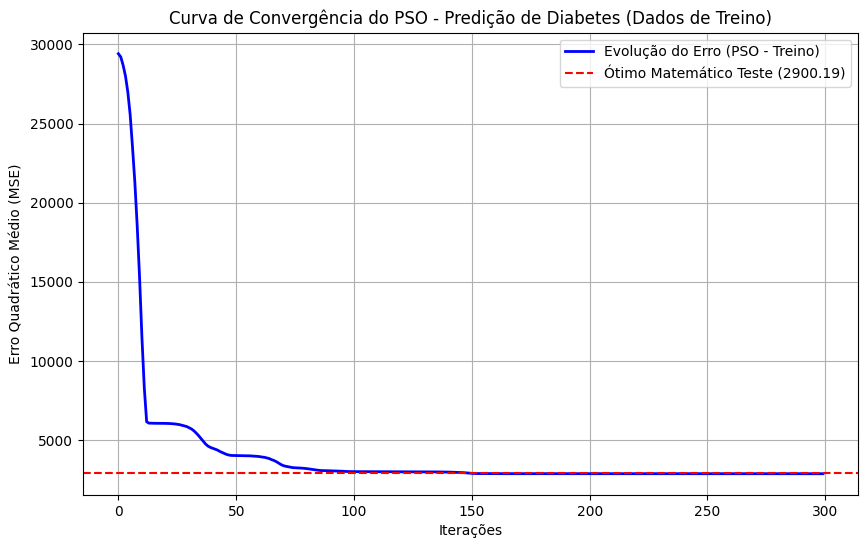

/tmp/ipykernel_8043/3339628093.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


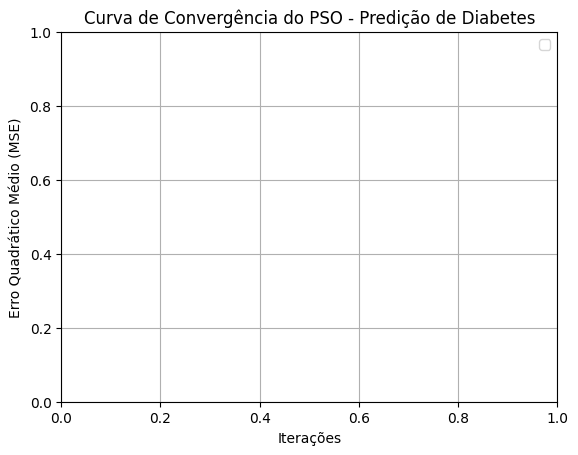

In [20]:
# 1. Executar o PSO mais potente APENAS com os dados de TREINO
print("A lançar 100 partículas para 300 iterações no conjunto de treino...")
melhor_vetor, melhor_score, historico = particle_swarm_optimization_history(fitness_function, X_train, y_train, p)

print(f"🔥 Melhor Fitness de Treino alcançado: {melhor_score:.4f}")

# Calcular o erro real deste melhor vetor nos dados de TESTE
# (Para sabermos quão bem ele se comporta com doentes novos)
melhor_score_teste = fitness_function(melhor_vetor, X_test, y_test)
print(f"⚡ Fitness Real nos dados de TESTE: {melhor_score_teste:.4f}")

# 2. Desenhar o Gráfico de Convergência (Histórico de Treino)
plt.figure(figsize=(10, 6))
plt.plot(historico, color='blue', linewidth=2, label='Evolução do Erro (PSO - Treino)')

# Adicionar a linha vermelha com o novo MSE perfeito de teste
plt.axhline(y=mse_teste_perfeito, color='red', linestyle='--', label=f'Ótimo Matemático Teste ({mse_teste_perfeito:.2f})')

plt.title('Curva de Convergência do PSO - Predição de Diabetes (Dados de Treino)')
plt.xlabel('Iterações')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

plt.title('Curva de Convergência do PSO - Predição de Diabetes')
plt.xlabel('Iterações')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Este bloco de código executa o PSO aprimorado e visualiza o seu processo de convergência:

1.  **Execução do PSO:** A função `particle_swarm_optimization_history` é chamada com os parâmetros definidos, e os resultados (`melhor_vetor`, `melhor_score` e `historico`) são armazenados.
2.  **Exibição do Novo Recorde:** O melhor score negativo alcançado pelo PSO é impresso, juntamente com o limite matemático (MSE do OLS) para fácil comparação.
3.  **Desenho do Gráfico de Convergência:**
    *   O `historico` de scores é plotado para mostrar como o Erro Quadrático Médio (MSE) evoluiu ao longo das iterações do PSO.
    *   É adicionada uma linha horizontal tracejada (`plt.axhline`) representando o "Ótimo Matemático" (o MSE do OLS). Isso permite visualizar o quão perto o PSO consegue chegar do limite teórico e a sua trajetória para alcançá-lo.
    *   São adicionados título, rótulos dos eixos e uma legenda para tornar o gráfico informativo e compreensível.

In [21]:
import numpy as np
import pandas as pd

# Listas para guardar os resultados das 10 corridas
melhores_scores_corridas = []
melhores_pesos_corridas = []

num_execucoes = 10

print(f"🚀 A iniciar o Teste de Robustez (A executar o PSO {num_execucoes} vezes)...")

for i in range(num_execucoes):
    # Executa o PSO que já definimos antes
    vetor, score, _ = particle_swarm_optimization_history(fitness_function, X, y, p, num_particles=100, max_iter=200)

    # Guardamos o erro real (positivo) para a análise estatística
    melhores_scores_corridas.append(-score)
    melhores_pesos_corridas.append(vetor)
    print(f"  Corrida {i+1}/{num_execucoes} concluída. MSE: {-score:.4f}")

# --- ANÁLISE ESTATÍSTICA ---
media_mse = np.mean(melhores_scores_corridas)
desvio_padrao_mse = np.std(melhores_scores_corridas)

print("\n" + "="*50)
print("📊 RESULTADOS ESTATÍSTICOS DO PSO (Para o Relatório)")
print("="*50)
print(f"Média do MSE: {media_mse:.4f}")
print(f"Desvio Padrão do MSE: {desvio_padrao_mse:.4f}")
print(f"Melhor MSE absoluto conseguido: {min(melhores_scores_corridas):.4f}")
print(f"Ótimo Matemático de referência (OLS): 2859.6963")
print("="*50)

# --- MAPEAR OS PESOS DA MELHOR CORRIDA ---
# Encontrar o índice da corrida que teve o menor erro (melhor performance)
melhor_corrida_idx = np.argmin(melhores_scores_corridas)
melhor_vetor_global = melhores_pesos_corridas[melhor_corrida_idx]

# Ir buscar os nomes originais das colunas (features) do teu dataset
df_original = pd.read_csv('diabetes_preprocessed.csv')
nomes_features = list(df_original.drop(columns=['target']).columns)
nomes_features.append("Intercept (Bias)") # O último elemento do vetor é o bias

print("\n🧬 PESOS ÓTIMOS DESCOBERTOS PELO TEU PSO:")
print("-" * 50)
for nome, peso in zip(nomes_features, melhor_vetor_global):
    print(f"{nome:<25} : {peso:.6f}")
print("-" * 50)


🚀 A iniciar o Teste de Robustez (A executar o PSO 10 vezes)...
  Corrida 1/10 concluída. MSE: 2859.7324
  Corrida 2/10 concluída. MSE: 2860.1008
  Corrida 3/10 concluída. MSE: 2860.6022
  Corrida 4/10 concluída. MSE: 2859.7952
  Corrida 5/10 concluída. MSE: 2861.1175
  Corrida 6/10 concluída. MSE: 2859.9296
  Corrida 7/10 concluída. MSE: 2859.7950
  Corrida 8/10 concluída. MSE: 2863.6592
  Corrida 9/10 concluída. MSE: 2859.7621
  Corrida 10/10 concluída. MSE: 2862.4942

📊 RESULTADOS ESTATÍSTICOS DO PSO (Para o Relatório)
Média do MSE: 2860.6988
Desvio Padrão do MSE: 1.2871
Melhor MSE absoluto conseguido: 2859.7324
Ótimo Matemático de referência (OLS): 2859.6963

🧬 PESOS ÓTIMOS DESCOBERTOS PELO TEU PSO:
--------------------------------------------------
age                       : -9.013070
sex                       : -239.622681
bmi                       : 520.176568
bp                        : 323.418414
s1                        : -762.933232
s2                        : 453.619959
s3

Este bloco de código realiza um **Teste de Robustez** do algoritmo PSO, executando-o várias vezes (neste caso, 10 vezes) para analisar a sua estabilidade e a consistência dos resultados.

1.  **Execuções Múltiplas do PSO:** O algoritmo PSO (`particle_swarm_optimization_history`) é executado `num_execucoes` (10) vezes.
2.  **Coleta de Resultados:** Para cada corrida:
    *   O MSE final (convertido para positivo) é armazenado em `melhores_scores_corridas`.
    *   O vetor de pesos ótimos encontrado é armazenado em `melhores_pesos_corridas`.
3.  **Análise Estatística:** Após todas as execuções, é calculada a `media_mse` e o `desvio_padrao_mse`. Isso nos dá uma ideia da performance média do PSO e da variabilidade dos seus resultados, indicando a sua robustez.
4.  **Comparação com OLS:** O `melhor MSE absoluto conseguido` entre todas as corridas é comparado com o `Ótimo Matemático de referência (OLS)` para verificar a proximidade do PSO à solução ideal.
5.  **Mapeamento dos Pesos da Melhor Corrida:**
    *   É identificado qual das 10 corridas obteve o menor MSE (a melhor performance).
    *   Os pesos correspondentes a essa melhor corrida (`melhor_vetor_global`) são recuperados.
    *   Os nomes das features originais do dataset são carregados e o termo de Intercept (Bias) é adicionado para corresponder ao tamanho do vetor de pesos.
    *   Finalmente, os `PESOS ÓTIMOS DESCOBERTOS PELO TEU PSO` são impressos de forma organizada, associando cada peso à sua feature correspondente. Isso permite interpretar a importância de cada característica na predição da progressão da doença.

In [22]:
import random
import numpy as np

# --- 1. SELEÇÃO ---
def tournament_selection(population, fitnesses, tournament_size=3, maximize=True):
    sample = random.sample(range(len(population)), tournament_size)
    best = sample[0]
    if maximize:
        for i in range(len(sample)):
            if fitnesses[sample[i]] > fitnesses[best]:
                best = sample[i]
    else:
        for i in range(len(sample)):
            if fitnesses[sample[i]] < fitnesses[best]:
                best = sample[i]
    return population[best]

# --- 2. OPERADORES DE CRUZAMENTO (CROSSOVER) ---
def single_point_crossover(parent1, parent2):
    """ Operador 1: Ponto Único (Troca as metades dos vetores) """
    p1, p2 = list(parent1), list(parent2)
    k = random.randint(1, len(p1) - 1)
    child1 = p1[:k] + p2[k:]
    child2 = p2[:k] + p1[k:]
    return np.array(child1), np.array(child2)

def arithmetic_crossover(parent1, parent2, alpha=0.5):
    """ Operador 2: Cruzamento Aritmético (Combinação linear / Média ponderada) """
    p1 = np.array(parent1)
    p2 = np.array(parent2)
    child1 = alpha * p1 + (1 - alpha) * p2
    child2 = (1 - alpha) * p1 + alpha * p2
    return child1, child2

# --- 3. OPERADORES DE MUTAÇÃO ---
def gaussian_mutation(individual, mutation_rate, scale=0.1):
    """ Operador 1: Mutação Gaussiana (Adiciona ruído decimal — Ideal para números reais) """
    individual_copy = np.array(individual).copy()
    for i in range(len(individual_copy)):
        if random.random() < mutation_rate:
            individual_copy[i] += np.random.normal(0, scale)
    return individual_copy

def random_resetting_mutation(individual, mutation_rate):
    """ Operador 2: Reinicialização Aleatória (Substitui por um novo número entre -1 e 1) """
    individual_copy = np.array(individual).copy()
    for i in range(len(individual_copy)):
        if random.random() < mutation_rate:
            individual_copy[i] = random.uniform(-1, 1)
    return individual_copy

print("✅ Célula 1: Operadores genéticos para números reais registados!")

✅ Célula 1: Operadores genéticos para números reais registados!


Este bloco de código define as funções essenciais que compõem os **operadores genéticos** de um Algoritmo Genético (AG), projetados para trabalhar com soluções representadas por números reais (vetores de pesos neste caso):

1.  **`tournament_selection(population, fitnesses, tournament_size=3, maximize=True)`**:
    *   **Função**: Seleciona um indivíduo (solução) da população para ser pai ou mãe na próxima geração.
    *   **Como funciona**: Escolhe `tournament_size` indivíduos aleatoriamente da população. Dentre eles, o indivíduo com o melhor *fitness* (pontuação) é selecionado. Isso garante que indivíduos mais aptos tenham maior probabilidade de reprodução, mas ainda permite uma pequena chance de indivíduos menos aptos contribuírem, o que ajuda a manter a diversidade genética.

2.  **Operadores de Cruzamento (`crossover`)**:
    *   **`single_point_crossover(parent1, parent2)`**:
        *   **Função**: Combina material genético de dois pais para criar dois filhos.
        *   **Como funciona**: Escolhe um ponto aleatório no vetor de pesos. Os filhos são criados trocando as partes do vetor a partir desse ponto entre os pais. Por exemplo, o filho 1 recebe a primeira parte do pai 1 e a segunda parte do pai 2.
    *   **`arithmetic_crossover(parent1, parent2, alpha=0.5)`**:
        *   **Função**: Cria filhos como uma combinação linear dos pais.
        *   **Como funciona**: Cada gene (peso) de um filho é uma média ponderada dos genes correspondentes dos pais, usando um parâmetro `alpha`. Isso é particularmente útil para problemas de otimização de valores reais, pois pode gerar soluções que estão

In [23]:
def genetic_algorithm(generate_solution, fitness_function, selection, crossover, mutation, pop_size, n_iter, mutation_rate, maximize=True):
    # 1. Inicializar a população aleatoriamente
    population = [generate_solution() for i in range(pop_size)]
    fitnesses = [fitness_function(ind) for ind in population]
    history = []

    if maximize:
        best_fitness = max(fitnesses)
        best_idx = np.argmax(fitnesses)
    else:
        best_fitness = min(fitnesses)
        best_idx = np.argmin(fitnesses)

    history.append(best_fitness)

    # 2. Ciclo principal das gerações
    for g in range(n_iter):
        new_population = []

        # Criar a nova geração de filhos
        while len(new_population) < pop_size:
            parent1 = selection(population, fitnesses, maximize=maximize)
            parent2 = selection(population, fitnesses, maximize=maximize)

            children = crossover(parent1, parent2)

            for child in children:
                mutated_child = mutation(child, mutation_rate)
                new_population.append(mutated_child)

        # Garantir que a população mantém o tamanho fixo
        new_population = new_population[:pop_size]
        population = new_population
        fitnesses = [fitness_function(ind) for ind in population]

        # Encontrar o melhor da geração atual
        if maximize:
            best_fitness = max(fitnesses)
            best_idx = np.argmax(fitnesses)
        else:
            best_fitness = min(fitnesses)
            best_idx = np.argmin(fitnesses)

        history.append(best_fitness)

        # Imprimir o relatório de progresso de 20 em 20 gerações
        if (g + 1) % 20 == 0 or g == 0:
            print(f"  Geração {g+1}: Melhor Fitness Atual = {best_fitness:.4f}")

    # Retorna os pesos do melhor indivíduo absoluto e o histórico
    return population[best_idx], history

print("✅ Célula 2: Motor do Algoritmo Genético registado!")

✅ Célula 2: Motor do Algoritmo Genético registado!


# EXPERIÊNCIA 1: GA com Parâmetros Padrão (Baseline)
# Torneio=3, Escala da Mutação=0.1, Taxa=0.1

🚀 A iniciar a evolução do Algoritmo Genético (100 indivíduos, 300 gerações)...
  Geração 1: Melhor Fitness Atual = -28788.1549
  Geração 20: Melhor Fitness Atual = -28620.8274
  Geração 40: Melhor Fitness Atual = -28399.2096
  Geração 60: Melhor Fitness Atual = -28233.1380
  Geração 80: Melhor Fitness Atual = -28046.3752
  Geração 100: Melhor Fitness Atual = -27804.6174
  Geração 120: Melhor Fitness Atual = -27643.7657
  Geração 140: Melhor Fitness Atual = -27425.5358
  Geração 160: Melhor Fitness Atual = -27223.9620
  Geração 180: Melhor Fitness Atual = -27065.4744
  Geração 200: Melhor Fitness Atual = -26924.0690
  Geração 220: Melhor Fitness Atual = -26700.8180
  Geração 240: Melhor Fitness Atual = -26508.2079
  Geração 260: Melhor Fitness Atual = -26322.9929
  Geração 280: Melhor Fitness Atual = -26135.6144
  Geração 300: Melhor Fitness Atual = -25987.6148

🔥 Treino Concluído! Melhor MSE final alcançado pelo GA: 25987.6148


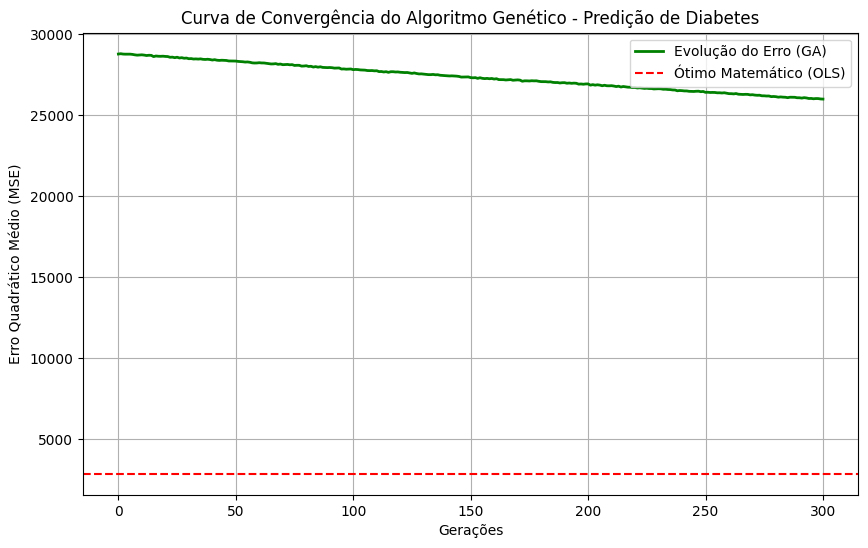

In [24]:
import matplotlib.pyplot as plt

# Criar os "embrulhos" para ligar o GA às variáveis X e y que já tens no teu Colab
generate_real_solution = lambda: generate_solution(p)
fitness_ga = lambda ind: fitness_function(ind, X, y)

print("🚀 A iniciar a evolução do Algoritmo Genético (100 indivíduos, 300 gerações)...")

# EXECUTAR O ALGORITMO
melhores_pesos_ga, historico_ga_raw = genetic_algorithm(
    generate_solution=generate_real_solution,
    fitness_function=fitness_ga,
    selection=tournament_selection,
    crossover=arithmetic_crossover,   # Podes trocar para: single_point_crossover
    mutation=gaussian_mutation,       # Podes trocar para: random_resetting_mutation
    pop_size=100,
    n_iter=300,
    mutation_rate=0.1,
    maximize=True
)

# Inverter o sinal do histórico para podermos ver o erro real (positivo) a descer no gráfico
historico_ga = [-score for score in historico_ga_raw]

print(f"\n🔥 Treino Concluído! Melhor MSE final alcançado pelo GA: {historico_ga[-1]:.4f}")

# --- DESENHAR O GRÁFICO ---
plt.figure(figsize=(10, 6))
plt.plot(historico_ga, color='green', linewidth=2, label='Evolução do Erro (GA)')
plt.axhline(y=2859.6963, color='red', linestyle='--', label='Ótimo Matemático (OLS)')
plt.title('Curva de Convergência do Algoritmo Genético - Predição de Diabetes')
plt.xlabel('Gerações')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# EXPERIÊNCIA 2: GA Turbo (Após Análise de Convergência Prematura)
# Torneio=7, Escala da Mutação=1.0, Taxa=0.2

🚀 A iniciar o GA Turbo (Mais pressão seletiva e mutações maiores)...
  Geração 1: Melhor Fitness Atual = -28595.8678
  Geração 20: Melhor Fitness Atual = -24057.3685
  Geração 40: Melhor Fitness Atual = -20072.0779
  Geração 60: Melhor Fitness Atual = -16652.4997
  Geração 80: Melhor Fitness Atual = -13481.4865
  Geração 100: Melhor Fitness Atual = -11322.9901
  Geração 120: Melhor Fitness Atual = -9080.4670
  Geração 140: Melhor Fitness Atual = -7529.8727
  Geração 160: Melhor Fitness Atual = -6450.6605
  Geração 180: Melhor Fitness Atual = -5905.8754
  Geração 200: Melhor Fitness Atual = -5732.9309
  Geração 220: Melhor Fitness Atual = -5613.5796
  Geração 240: Melhor Fitness Atual = -5501.1468
  Geração 260: Melhor Fitness Atual = -5376.3261
  Geração 280: Melhor Fitness Atual = -5280.6198
  Geração 300: Melhor Fitness Atual = -5174.5716

🔥 GA Turbo Concluído! Melhor MSE final: 5174.5716


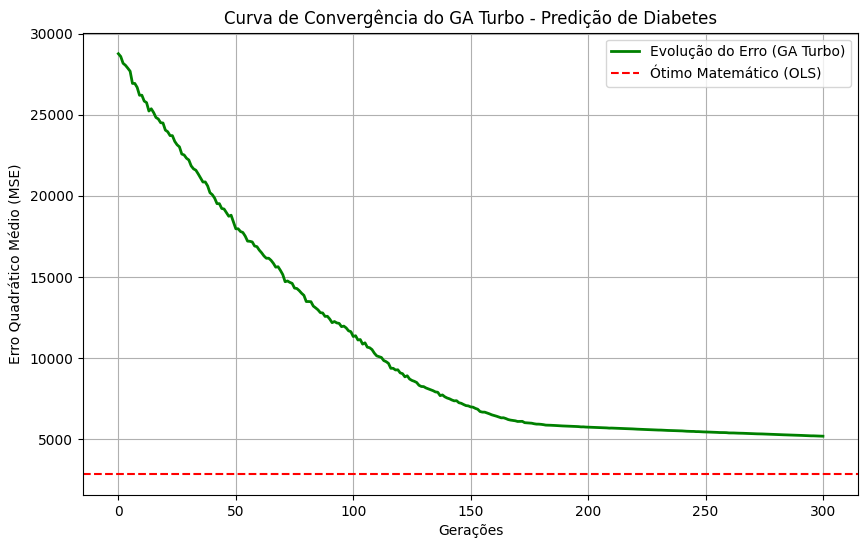

In [25]:
import matplotlib.pyplot as plt

# 1. Recriar os embrulhos ajustando o tamanho do torneio e a força da mutação
generate_real_solution = lambda: generate_solution(p)
fitness_ga = lambda ind: fitness_function(ind, X, y)

# Forçar o torneio a ser mais rigoroso (tamanho 7 em vez de 3)
selection_rigorosa = lambda pop, fit, maximize: tournament_selection(pop, fit, tournament_size=7, maximize=maximize)

# Forçar a mutação a dar passos muito maiores (scale=1.0 em vez de 0.1)
mutation_agressiva = lambda ind, rate: gaussian_mutation(ind, rate, scale=1.0)

print("🚀 A iniciar o GA Turbo (Mais pressão seletiva e mutações maiores)...")

# EXECUTAR O ALGORITMO
melhores_pesos_ga, historico_ga_raw = genetic_algorithm(
    generate_solution=generate_real_solution,
    fitness_function=fitness_ga,
    selection=selection_rigorosa,     # Torneio mais competitivo
    crossover=arithmetic_crossover,
    mutation=mutation_agressiva,      # Passos maiores no terreno
    pop_size=100,
    n_iter=300,
    mutation_rate=0.2,                # Taxa de mutação mais alta (20%)
    maximize=True
)

# Inverter o sinal do histórico para o gráfico
historico_ga = [-score for score in historico_ga_raw]

print(f"\n🔥 GA Turbo Concluído! Melhor MSE final: {historico_ga[-1]:.4f}")

# --- DESENHAR O GRÁFICO ---
plt.figure(figsize=(10, 6))
plt.plot(historico_ga, color='green', linewidth=2, label='Evolução do Erro (GA Turbo)')
plt.axhline(y=2859.6963, color='red', linestyle='--', label='Ótimo Matemático (OLS)')
plt.title('Curva de Convergência do GA Turbo - Predição de Diabetes')
plt.xlabel('Gerações')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.show()